In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
main_path = os.getcwd()

import sys
sys.path.append(main_path)
from analysis.libraries.survival import plot_km_two_groups

In [18]:
base_dir = os.path.join(main_path, 'data/results/survival-risk-groups')

In [19]:
sns.set_context("paper", font_scale=2.0)

def plot_risk_groups(panel, base_dir, ax=None):
    data_dir = os.path.join(base_dir, panel)
    high_risk = pd.read_csv(os.path.join(data_dir, 'high_risk_group.csv'))
    high_risk['risk_group'] = 1
    low_risk = pd.read_csv(os.path.join(data_dir, 'low_risk_group.csv'))
    low_risk['risk_group'] = 0
    all_risk = pd.concat([low_risk, high_risk])
    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5,7))
    plot_km_two_groups(df=all_risk, 
                   event_ind_field='os_event_ind', 
                   event_data_field='os_event_data', 
                   group_col='risk_group', 
                   max_months=60, 
                   add_counts=False, 
                   title=panel.capitalize(), 
                   ci_show=False, 
                   ax=ax)
    
    return ax, data_dir


In [20]:
from lifelines import CoxPHFitter
import pickle

def load_model(base_dir, panel):
    model_path = os.path.join(base_dir, panel, 'model.pickle')
    save_path = os.path.join(base_dir, panel)
    with open(model_path, 'rb') as file:
        cph = pickle.load(file)
        return cph, save_path

### Main figure KMs

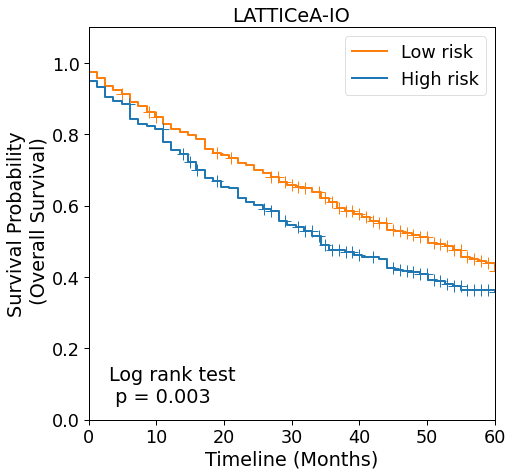

In [21]:
ax, save_dir = plot_risk_groups('bioclavis', base_dir=base_dir)

ax.set_title('LATTICeA-IO')
plt.savefig(os.path.join(save_dir, 'latticea-io-km-high-low.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

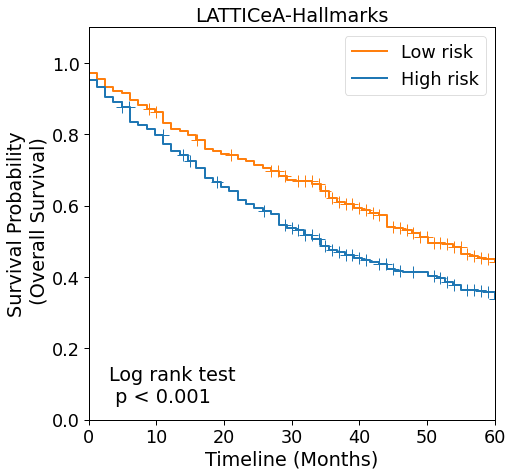

In [22]:
ax, save_dir = plot_risk_groups('hallmarks', base_dir=base_dir)

ax.set_title('LATTICeA-Hallmarks')
plt.savefig(os.path.join(save_dir, 'latticea-hallmarks-km-high-low.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

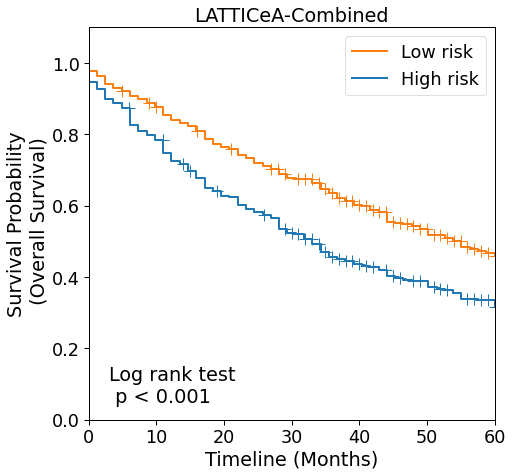

In [23]:
ax, save_dir = plot_risk_groups('combined-latticeA', base_dir=base_dir)

ax.set_title('LATTICeA-Combined')
plt.savefig(os.path.join(save_dir, 'latticea-combined-km-high-low.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

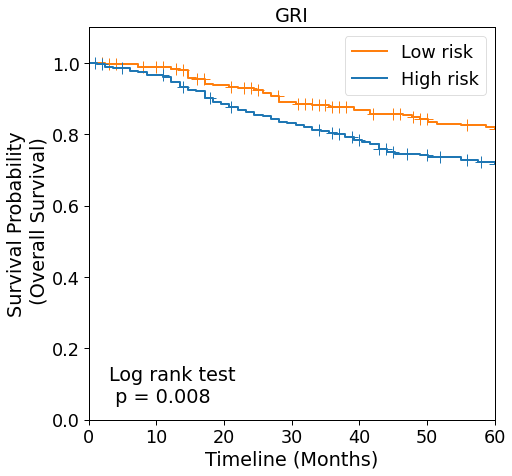

In [24]:
ax, save_dir = plot_risk_groups('gri', base_dir=base_dir)

ax.set_title('GRI')
plt.savefig(os.path.join(save_dir, 'gri-km-high-low.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

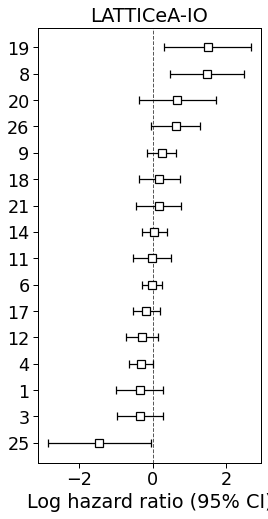

In [25]:
cph, save_dir = load_model(base_dir=base_dir, panel='bioclavis')

fig, ax = plt.subplots(figsize=(4,8))
cph.plot(ax=ax, ms=8, capsize=4)
ax.set_title('LATTICeA-IO')
ax.set_xlabel('Log hazard ratio (95% CI)')

plt.savefig(os.path.join(save_dir, 'bioclavis-forest.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

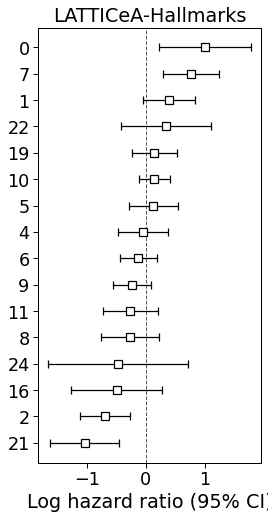

In [26]:
cph, save_dir = load_model(base_dir=base_dir, panel='hallmarks')

fig, ax = plt.subplots(figsize=(4,8))
cph.plot(ax=ax, ms=8, capsize=4)
ax.set_title('LATTICeA-Hallmarks')
ax.set_xlabel('Log hazard ratio (95% CI)')

plt.savefig(os.path.join(save_dir, 'hallmarks-forest.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

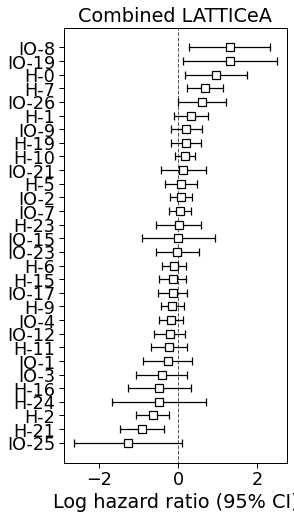

In [27]:
cph, save_dir = load_model(base_dir=base_dir, panel='combined-latticeA')

fig, ax = plt.subplots(figsize=(4,8))
cph.plot(ax=ax, ms=8, capsize=4)
ax.set_title('Combined LATTICeA')
ax.set_xlabel('Log hazard ratio (95% CI)')

panel_dict = {'0':'IO', '1':'H'}
new_ylabs = list()

for label in ax.get_yticklabels():
    current_text = label.get_text()
    current_text = current_text.split('_')
    updated_text = list()
    updated_text.append(current_text[0])
    updated_text.append(panel_dict[current_text[1]])
    updated_text = updated_text[::-1]
    label_text = '-'.join(updated_text)
    new_ylabs.append(label_text)

ax.set_yticklabels(new_ylabs)
plt.savefig(os.path.join(save_dir, 'combined-latticeA-forest.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

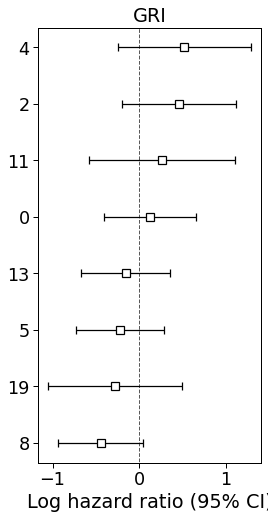

In [28]:
cph, save_dir = load_model(base_dir=base_dir, panel='gri')

fig, ax = plt.subplots(figsize=(4,8))
cph.plot(ax=ax, ms=8, capsize=4)
ax.set_title('GRI')
ax.set_xlabel('Log hazard ratio (95% CI)')

plt.savefig(os.path.join(save_dir, 'gri-forest.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

### PD-L1 Positive KMs

In [29]:
base_dir = os.path.join(main_path, 'data/results/survival-risk-groups/pdl1-pos')

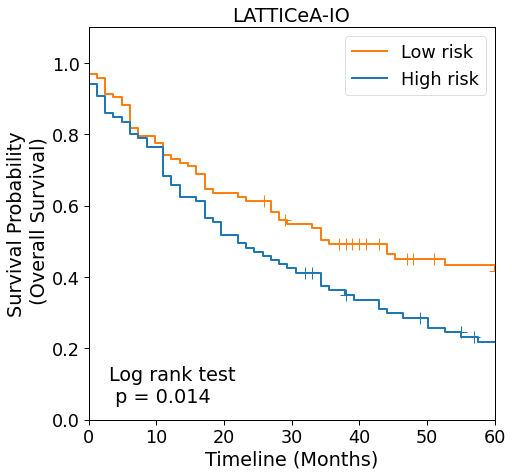

In [30]:
ax, save_dir = plot_risk_groups('bioclavis-latticeA', base_dir=base_dir)

ax.set_title('LATTICeA-IO')
plt.savefig(os.path.join(save_dir, 'bioclavis-pdl1-pos-high-low.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

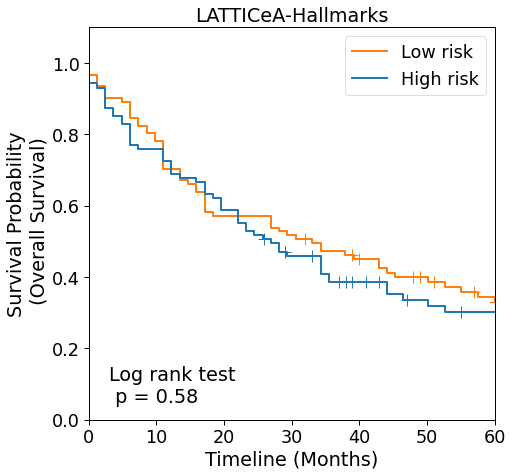

In [31]:
ax, save_dir = plot_risk_groups('hallmarks-latticeA', base_dir=base_dir)

ax.set_title('LATTICeA-Hallmarks')
plt.savefig(os.path.join(save_dir, 'hallmarks-pdl1-pos-high-low.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

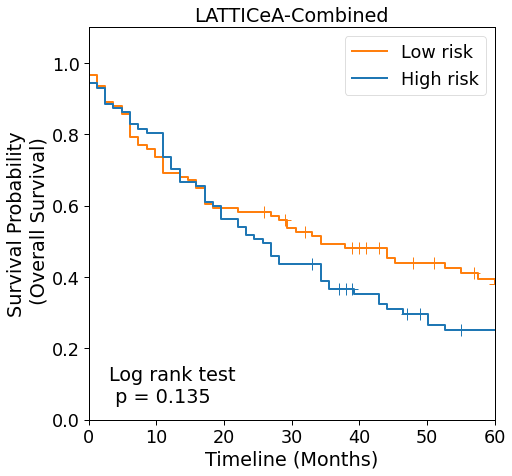

In [32]:
ax, save_dir = plot_risk_groups('combined-latticeA', base_dir=base_dir)

ax.set_title('LATTICeA-Combined')
plt.savefig(os.path.join(save_dir, 'combined-pdl1-pos-high-low.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

### PD-L1 Positive Neighbourhoods

In [33]:
base_dir = os.path.join(main_path, 'data/results/survival-risk-groups/pdl1-pos/counts-based-neighbourhood-analysis')

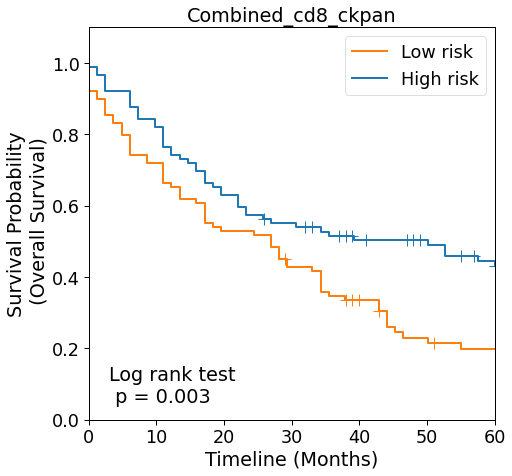

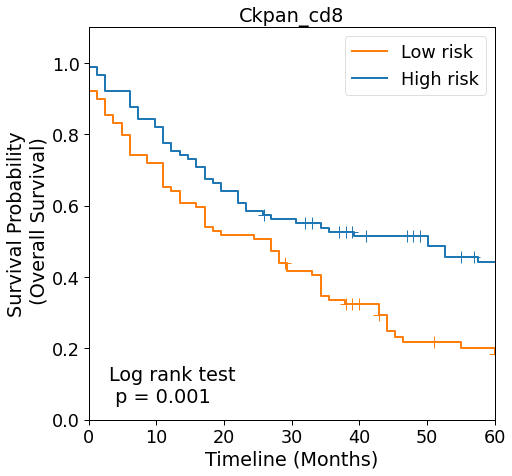

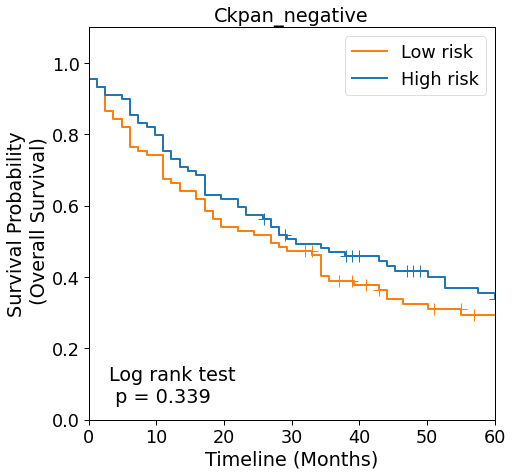

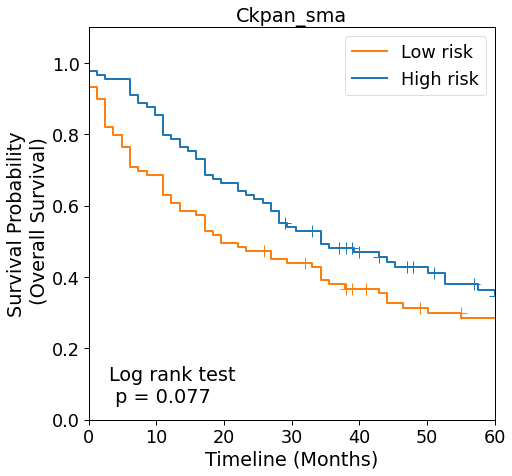

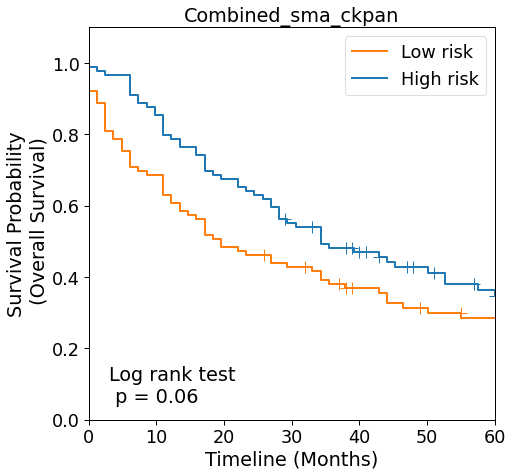

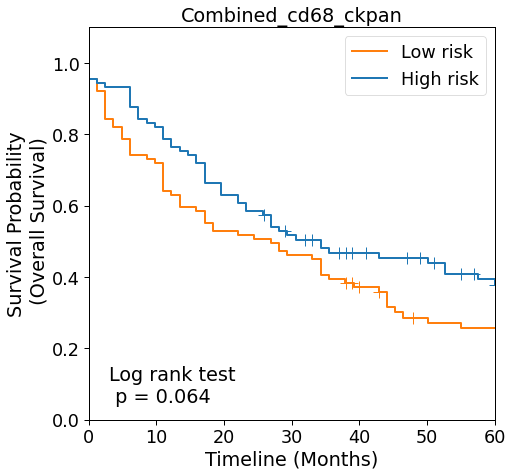

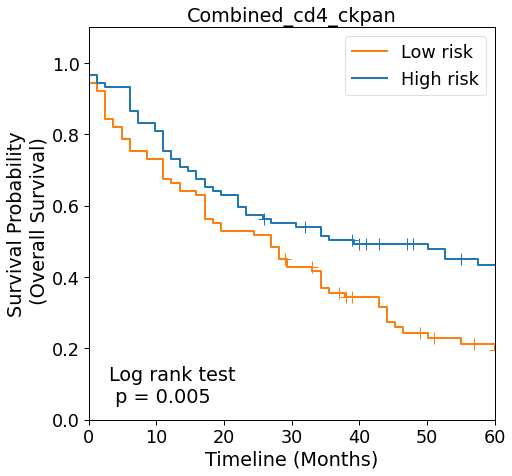

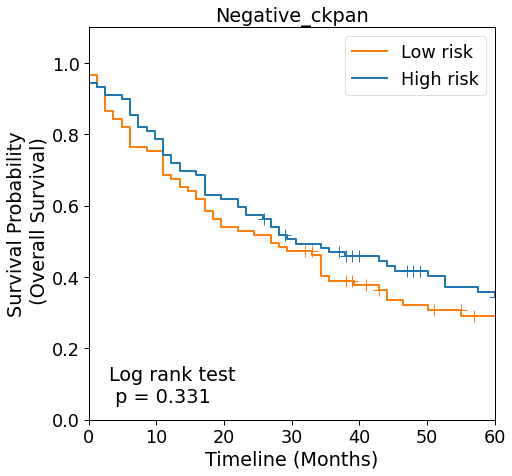

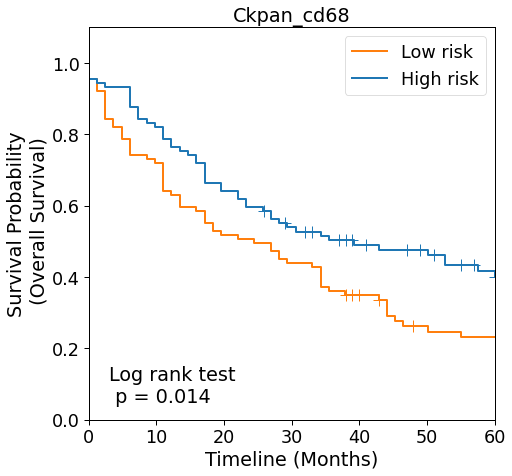

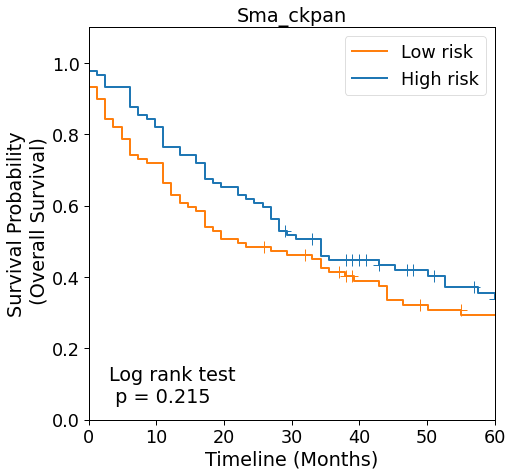

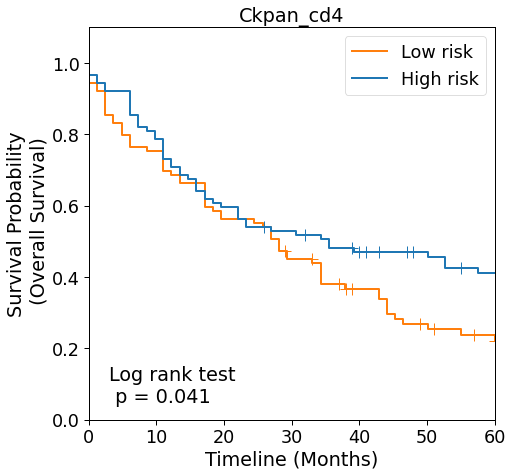

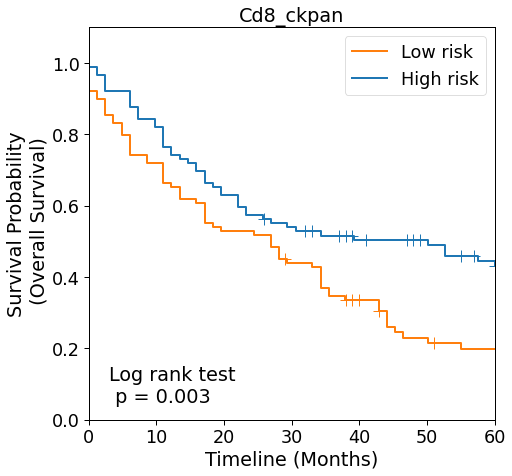

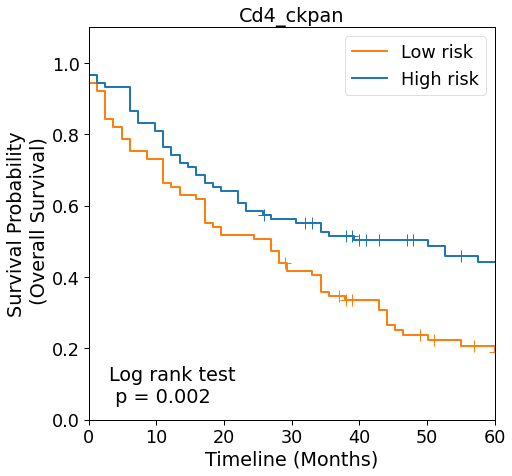

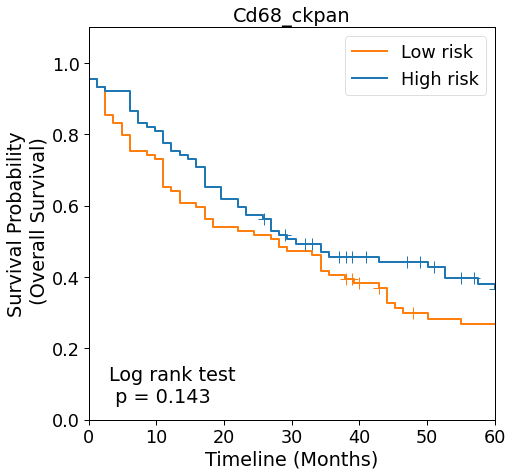

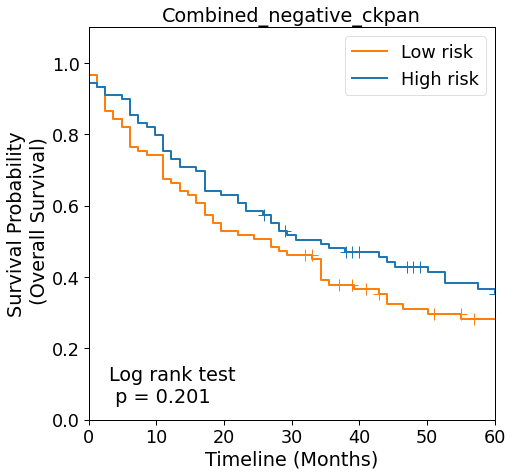

In [36]:
for folder in os.scandir(base_dir):
    folder_basename = os.path.basename(folder)
    ax, save_dir = plot_risk_groups(folder_basename, base_dir=base_dir)
    ax.set_title(folder_basename.capitalize())
    plt.savefig(os.path.join(save_dir, f'{folder_basename}-pdl1-pos-high-low.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

### Forest plots

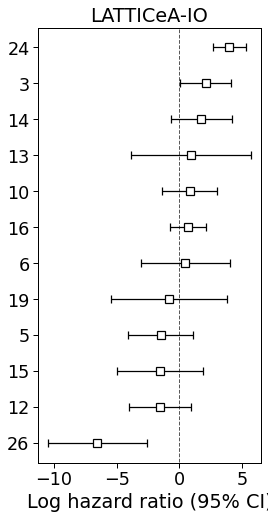

In [18]:
cph, save_dir = load_model(base_dir=base_dir, panel='bioclavis-latticeA')

fig, ax = plt.subplots(figsize=(4,8))
cph.plot(ax=ax, ms=8, capsize=4)
ax.set_title('LATTICeA-IO')
ax.set_xlabel('Log hazard ratio (95% CI)')

plt.savefig(os.path.join(save_dir, 'pdl1-pos-bioclavis-forest.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

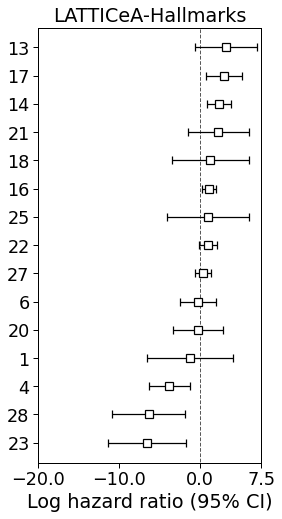

In [19]:
cph, save_dir = load_model(base_dir=base_dir, panel='hallmarks-latticeA')

fig, ax = plt.subplots(figsize=(4,8))
cph.plot(ax=ax, ms=8, capsize=4)

ax.set_title('LATTICeA-Hallmarks')
ax.set_xlim([-20, 7.5])
ax.set_xticks([-20, -10, 0, 7.5])
ax.set_xlabel('Log hazard ratio (95% CI)')

plt.savefig(os.path.join(save_dir, 'pdl1-pos-hallmarks-forest.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

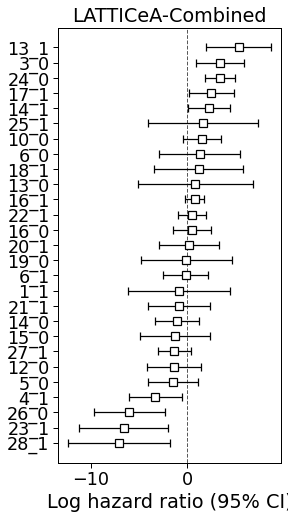

In [20]:
cph, save_dir = load_model(base_dir=base_dir, panel='combined-latticeA')

fig, ax = plt.subplots(figsize=(4,8))
cph.plot(ax=ax, ms=8, capsize=4)
ax.set_title('LATTICeA-Combined')
ax.set_xlabel('Log hazard ratio (95% CI)')

plt.savefig(os.path.join(save_dir, 'pdl1-pos-combined-forest.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)